# Task 4: Quantization Error at Different Bit Widths

## Objective

Study how quantization error changes as the number of bits is reduced from **8** to **6** to **4**.

---

## Input

```python
tensor = np.array([
    [-1.8, -0.9, 0.0, 0.7, 1.5],
    [-2.4, -0.3, 0.2, 1.1, 2.0]
], dtype=np.float32)
```

---

# Bit Width Specifications

For each bit width **b**, use **symmetric quantization**.

### Quantization Equations

```text
q_min = -(2^(b-1)) + 1

q_max = (2^(b-1)) - 1

scale = max(|x_min|, |x_max|) / q_max

zero_point = 0
```

---

## Bit Width Configuration

| Bits | q_min | q_max | Representable Levels |
|------:|------:|------:|---------------------:|
| 8 | -127 | 127 | 255 |
| 6 | -31 | 31 | 63 |
| 4 | -7 | 7 | 15 |

---

# Implementation

```python
def quantize_at_bitwidth(tensor, bits):
    """
    Perform symmetric quantization at the specified bit width.

    Returns:
        quantized_tensor
        dequantized_tensor
        scale
    """
    pass
```

---

# Expected Output

Compute the quantization statistics for each bit width.

| Bits | q_min | q_max | Levels | Scale | MAE | MSE | Max Error |
|------:|------:|------:|-------:|------:|----:|----:|----------:|
| 8 | -127 | 127 | 255 | | | | |
| 6 | -31 | 31 | 63 | | | | |
| 4 | -7 | 7 | 15 | | | | |

---

# Visualization

Create the following plots.

## 1. Original vs Dequantized Values

Overlay the original tensor values with the dequantized values obtained using:

- 8-bit quantization
- 6-bit quantization
- 4-bit quantization

Use different colors for each bit width.

---

## 2. MSE vs Bit Width

Create a **bar chart** showing the Mean Squared Error (MSE) for:

- 8-bit
- 6-bit
- 4-bit

---

## 3. Max Error vs Bit Width

Create a **bar chart** showing the Maximum Absolute Error for:

- 8-bit
- 6-bit
- 4-bit

---

# Deliverable

Your notebook should include:

- ✅ Implementation of symmetric quantization for arbitrary bit widths
- ✅ Quantization results for 8-bit, 6-bit, and 4-bit
- ✅ Completed comparison table
- ✅ Original vs dequantized overlay plot
- ✅ MSE vs bit width bar chart
- ✅ Maximum error vs bit width bar chart
- ✅ Written observations discussing:
  - How quantization error changes as bit width decreases
  - Trade-off between model size and numerical accuracy
  - Why lower bit widths increase quantization error
  - Which bit width provides the best balance between compression and accuracy

In [4]:
import torch
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
tensor = torch.tensor([
    [-1.8, -0.9, 0.0, 0.7, 1.5],
    [-2.4, -0.3, 0.2, 1.1, 2.0]
], dtype=torch.float32)

In [6]:
def quantize_at_bitwidth(tensor, bits):
    """
    Perform symmetric quantization for the given bit width.
    Returns:
        quantized_tensor,
        dequantized_tensor,
        scale
    """

    q_min = -(2 ** (bits - 1)) + 1
    q_max = (2 ** (bits - 1)) - 1

    max_abs = torch.max(torch.abs(tensor)).item()

    if max_abs == 0:
        scale = 1.0
    else:
        scale = max_abs / q_max

    q = torch.round(tensor / scale)
    q = torch.clamp(q, q_min, q_max).to(torch.int8)

    dq = q.float() * scale

    return q, dq, scale

In [7]:
bit_widths = [8, 6, 4]

results = []

dequantized_outputs = {}

for bits in bit_widths:

    q, dq, scale = quantize_at_bitwidth(tensor, bits)

    error = tensor - dq

    mae = torch.mean(torch.abs(error)).item()
    mse = torch.mean(error ** 2).item()
    max_error = torch.max(torch.abs(error)).item()

    q_min = -(2 ** (bits - 1)) + 1
    q_max = (2 ** (bits - 1)) - 1
    levels = q_max - q_min + 1

    results.append({
        "Bits": bits,
        "q_min": q_min,
        "q_max": q_max,
        "Levels": levels,
        "Scale": scale,
        "MAE": mae,
        "MSE": mse,
        "Max Error": max_error
    })

    dequantized_outputs[bits] = dq

In [8]:
df = pd.DataFrame(results)

print(df)

   Bits  q_min  q_max  Levels     Scale       MAE       MSE  Max Error
0     8   -127    127     255  0.018898  0.003701  0.000022   0.007874
1     6    -31     31      63  0.077419  0.015161  0.000363   0.032258
2     4     -7      7      15  0.342857  0.067143  0.007122   0.142857


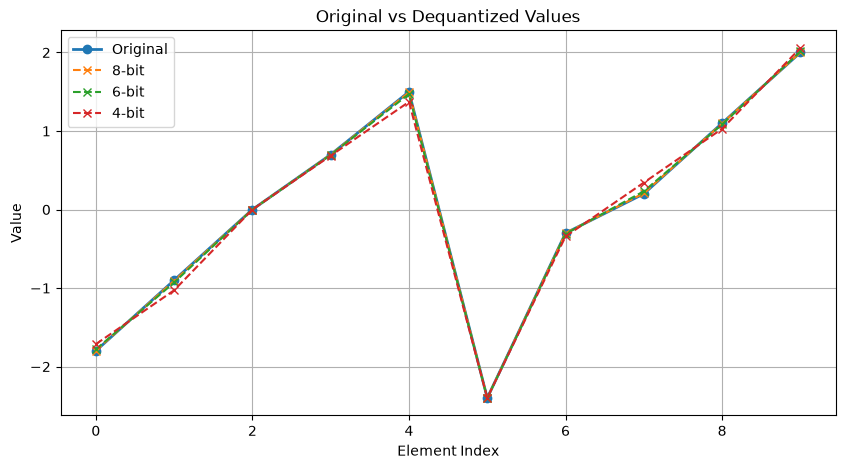

In [9]:
original = tensor.flatten().numpy()

plt.figure(figsize=(10,5))

plt.plot(
    original,
    marker='o',
    linewidth=2,
    label='Original'
)

for bits in bit_widths:

    plt.plot(
        dequantized_outputs[bits].flatten().numpy(),
        marker='x',
        linestyle='--',
        label=f'{bits}-bit'
    )

plt.title("Original vs Dequantized Values")
plt.xlabel("Element Index")
plt.ylabel("Value")
plt.grid(True)
plt.legend()
plt.show()

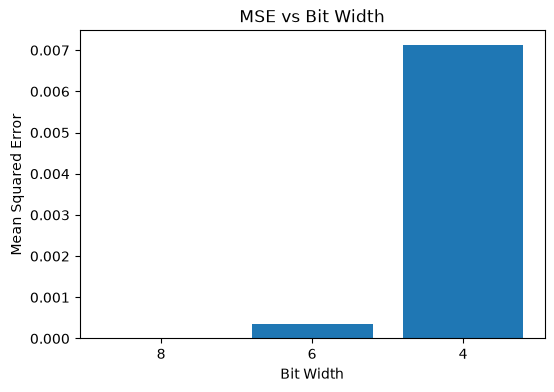

In [10]:
plt.figure(figsize=(6,4))

plt.bar(
    [str(b) for b in bit_widths],
    df["MSE"]
)

plt.title("MSE vs Bit Width")
plt.xlabel("Bit Width")
plt.ylabel("Mean Squared Error")

plt.show()

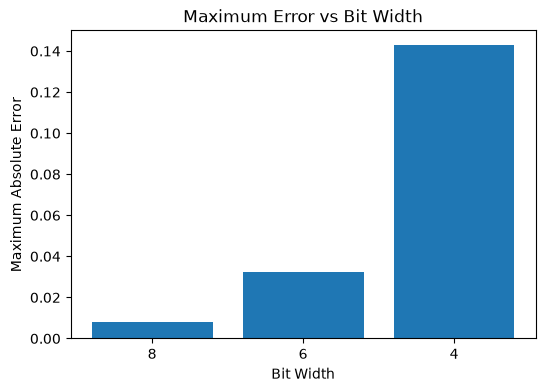

In [11]:
plt.figure(figsize=(6,4))

plt.bar(
    [str(b) for b in bit_widths],
    df["Max Error"]
)

plt.title("Maximum Error vs Bit Width")
plt.xlabel("Bit Width")
plt.ylabel("Maximum Absolute Error")

plt.show()